# O Quadrante Mágico do Cinema: Rentabilidade por Género

**Objetivo:** Cruzar a análise de gêneros narrativos com os indicadores financeiros (Orçamento e ROI) para descobrir o modelo de negócio mais eficiente da indústria cinematográfica contemporânea.


### Perguntas de Negócio
1. **O Custo do Género:**  Quais são os gêneros mais caros de produzir e quais operam sob um modelo low-budget?
   
2. **A Eficiência do Retorno:** Que tipo de filme garante as maiores margens de lucro (ROI) para os estúdios, minimizando o risco financeiro?
   
3. **O Quadrante Mágico:** É possível encontrar um gênero que combine Alto Retorno Financeiro (ROI) com Alta Perceção Qualitativa (Boa Nota Média), ou Hollywood tem de escolher entre Lucro e Prestígio?

In [2]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
import textwrap
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas_datareader.data as web # Biblioteca para consumir APIs financeiras
from matplotlib.colors import TwoSlopeNorm

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.io.db_client as dbc
import src.view.tables as tb
import src.view.plots as graf
import src.view.plots._formatters as fmtt

---
## Caminho central para a base de dados relacional


In [3]:
caminho_banco = '../../data/processed/unified_media_catalog.db'

---
## DataFrame Financeiro Base para Demais Análises 

In [4]:
query_finalcial_base = """
    SELECT
        g.id,
        g.genres,
        c.budget,
        c.revenue,
        c.global_score
    FROM unified_media_genres as g
    INNER JOIN unified_media_catalog as c
        ON c.id = g.id
    WHERE g.media_type = 'Movie'
        AND c.budget > 0;
"""

df_financial_base  = dbc.execute_query(
    caminho_db=caminho_banco,
    alvo=query_finalcial_base,
    eh_query=True
)


Dados carregados via SQL! Formato: (21178, 5)


---
## O Custo do Género

In [5]:
df_budget_genres = (
    df_financial_base  
    .groupby('genres')
    .agg(
        quantidade_filmes=('budget', 'count'),
        budget_medio=('budget', 'mean'),
        budget_mediano=('budget', 'median')
    )
    .round(2)
    .reset_index()
)

display(
    tb.estilizar_tabela(
        df=df_budget_genres
        .sort_values('budget_mediano', ascending=False)
        .set_index('genres'),
        caption=f'Custo de Produção por Gênero Cinematográfico'
    )
    .bar(subset=['quantidade_filmes'], color='#1D3557')
    .background_gradient(subset=['budget_medio'],cmap='YlGn')
    .background_gradient(subset=['budget_mediano'],cmap='Greens')
    .format({
        'quantidade_filmes': '{:,.0f}',
        'budget_medio': lambda x: '-' if pd.isna(x) else f'US$ {x:,.0f}',
        'budget_mediano': lambda x: '-' if pd.isna(x) else f'US$ {x:,.0f}'
    })
)

,quantidade_filmes,budget_medio,budget_mediano
genres,,,
Family,708,"US$ 47,511,412","US$ 30,000,000"
Animation,411,"US$ 48,653,886","US$ 28,000,000"
Adventure,"1,264","US$ 52,165,183","US$ 28,000,000"
Fantasy,717,"US$ 47,837,112","US$ 25,000,000"
Action,"2,071","US$ 37,514,060","US$ 18,000,000"
History,372,"US$ 23,955,079","US$ 14,867,000"
Mystery,631,"US$ 22,864,160","US$ 13,000,000"
Science Fiction,984,"US$ 35,982,555","US$ 13,000,000"
Crime,"1,232","US$ 22,472,272","US$ 12,125,000"


In [6]:
def graf_genres_financial(df, col_x, col_y, tipo_dado='US$'):
    plt.figure(figsize=(12, 7), dpi=150)

    df_high = (
        df
        .sort_values(col_x)
    )

    # Definição das cores das barras
    if tipo_dado == '%':
        minimo = df_high[col_x].min()
        maximo = df_high[col_x].max()

        if minimo < 0 and maximo > 0:
            # Valores positivos e negativos
            norm = TwoSlopeNorm(
                vmin=minimo,
                vcenter=0,
                vmax=maximo
            )
            cores = plt.cm.RdYlGn(norm(df_high[col_x]))

        elif maximo <= 0:
            # Todos negativos
            norm = plt.Normalize(minimo, 0)
            cores = plt.cm.Reds_r(norm(df_high[col_x]))

        else:
            # Todos positivos
            norm = plt.Normalize(0, maximo)
            cores = plt.cm.Greens(norm(df_high[col_x]))

    else:
        # Dados monetários
        cores = '#2A9D8F'

    # Criação das barras
    bars = plt.barh(
        df_high[col_y],
        df_high[col_x],
        color=cores
    )

    # Rótulos das barras
    for bar in bars:
        valor = bar.get_width()

        if tipo_dado == 'US$':
            texto = f'US$ {valor/1e6:.1f}M'

        elif tipo_dado == '%':
            texto = f'{valor:.1f}%'

        else:
            texto = f'{valor:.1f}'

        plt.text(
            valor,
            bar.get_y() + bar.get_height() / 2,
            f' {texto}',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

    # Formatação do eixo X
    ax = plt.gca()

    if tipo_dado == 'US$':
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(fmtt._formatar_dinheiro)
        )

    elif tipo_dado == '%':
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x:.0f}%')
        )

        # Linha de equilíbrio do ROI
        plt.axvline(
            0,
            color='black',
            linestyle='--',
            linewidth=1,
            alpha=0.7
        )

    # Estética final
    plt.xlabel('')
    plt.ylabel('')
    plt.grid(
        axis='x',
        linestyle='--',
        alpha=0.3
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

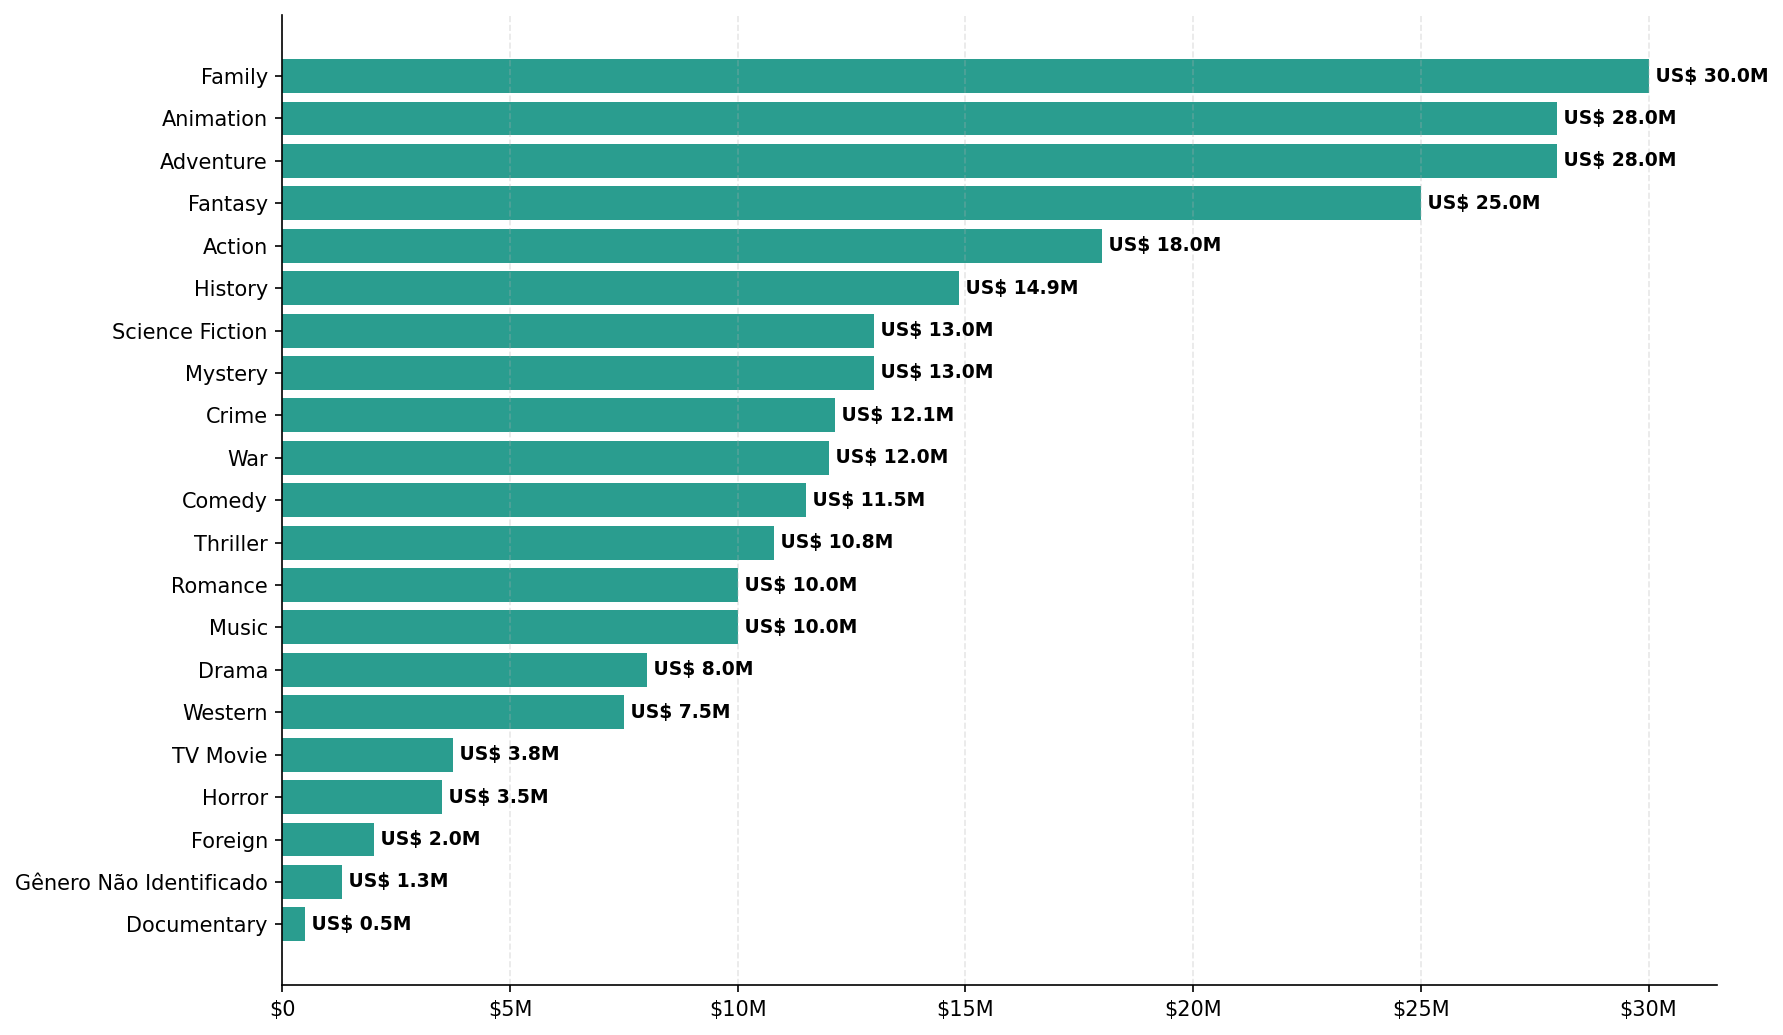

In [7]:
graf_genres_financial(
    df=df_budget_genres, 
    col_y='genres', 
    col_x='budget_mediano'
)

---
## A Eficiência do Retorno

In [8]:
df_financial_base['roi_filme'] = (
    (df_financial_base['revenue'] - df_financial_base['budget'])
    / df_financial_base['budget']
) * 100

df_roi_genres = (
    df_budget_genres
    .merge(
        df_financial_base
        .groupby('genres')
        .agg(
            roi_medio=('roi_filme', 'mean'),
            roi_mediano=('roi_filme', 'median')
        )
        .round(2)
        .reset_index(),
        on='genres',
        how='left'
    )
)

if (df_roi_genres[['roi_medio', 'roi_mediano']] < 0).any().any():
    cmap_roi = 'RdYlGn'
else:
    cmap_roi = 'Greens'

display(
    tb.estilizar_tabela(
        df=df_roi_genres
        .sort_values('roi_mediano', ascending=False)
        .set_index('genres'),
        colunas_selecionadas=['quantidade_filmes', 'roi_medio', 'roi_mediano'],
        caption='Retorno Financeiro por Gênero Cinematográfico (ROI, Receita e Custo)'
    )
    .bar(subset=['quantidade_filmes'], color='#1D3557')
    .background_gradient(subset=['roi_medio', 'roi_mediano'], cmap=cmap_roi)
    .format({
        'quantidade_filmes': '{:,.0f}',
        'roi_medio': lambda x: '-' if pd.isna(x) else f'{x:.2f}%',
        'roi_mediano': lambda x: '-' if pd.isna(x) else f'{x:.2f}%'
    })
)
 

,quantidade_filmes,roi_medio,roi_mediano
genres,,,
TV Movie,40,740.00%,740.00%
Animation,411,577.20%,177.84%
Horror,"1,227",3987.58%,151.19%
Family,708,438.76%,148.33%
Music,291,498.40%,145.45%
Documentary,190,1536.15%,140.00%
Adventure,"1,264",576.42%,129.08%
Fantasy,717,496.78%,115.19%
Romance,"1,431",381.84%,112.29%


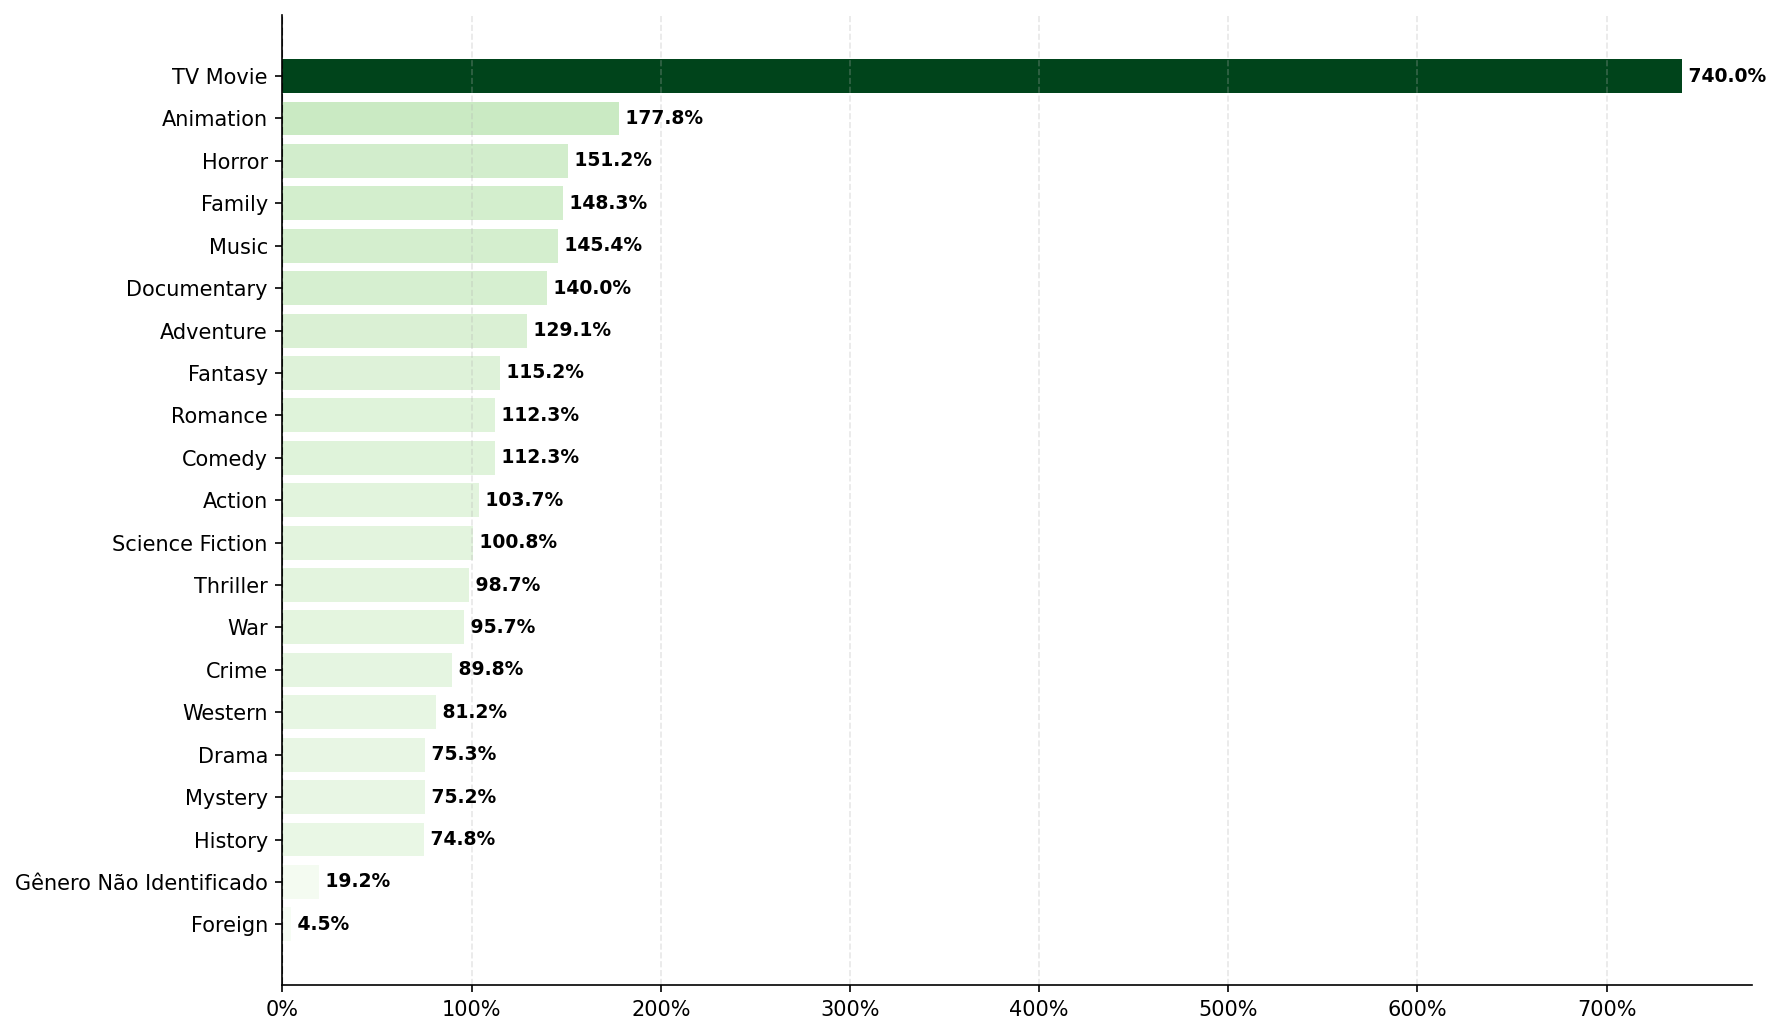

In [9]:
graf_genres_financial(
    df=df_roi_genres, 
    col_y='genres',
    col_x='roi_mediano',
    tipo_dado='%'
)

---
## O Quadrante Mágico

In [10]:
df_score_roi_genres = (
    df_roi_genres
    .merge(
        df_financial_base
        .groupby('genres')
        .agg(
            global_score_medio=('global_score', 'mean'),
            global_score_mediano=('global_score', 'median')
        )
        .round(2)
        .reset_index(),
        on='genres',
        how='left'
    )
)

display(
    tb.estilizar_tabela(
        df=df_score_roi_genres
        .sort_values('roi_mediano', ascending=False)
        .set_index('genres'),
        colunas_selecionadas=[
            'quantidade_filmes',
            'roi_medio', 
            'roi_mediano', 
            'global_score_medio', 
            'global_score_mediano'
        ],
        caption='Retorno Financeiro e Avaliação Crítica por Gênero Cinematográfico'
    )
    .bar(subset=['quantidade_filmes'],color='#1D3557')
    .background_gradient(subset=['roi_medio', 'roi_mediano'],cmap='Greens')
    .background_gradient(subset=['global_score_medio', 'global_score_mediano'],cmap='PuBu')
    .format({
        'quantidade_filmes': '{:,.0f}',
        'roi_medio': lambda x: 'NaN' if pd.isna(x) else f'{x:.2f}%',
        'roi_mediano': lambda x: 'NaN' if pd.isna(x) else f'{x:.2f}%',
        'global_score_medio': lambda x: 'NaN' if pd.isna(x) else f'{x:.2f}',
        'global_score_mediano': lambda x: 'NaN' if pd.isna(x) else f'{x:.2f}'
    })
)



,quantidade_filmes,roi_medio,roi_mediano,global_score_medio,global_score_mediano
genres,,,,,
TV Movie,40,740.00%,740.00%,50.30,50.00
Animation,411,577.20%,177.84%,64.05,65.00
Horror,"1,227",3987.58%,151.19%,54.76,56.00
Family,708,438.76%,148.33%,60.21,61.00
Music,291,498.40%,145.45%,64.38,65.00
Documentary,190,1536.15%,140.00%,65.89,68.00
Adventure,"1,264",576.42%,129.08%,60.78,61.00
Fantasy,717,496.78%,115.19%,60.05,61.00
Romance,"1,431",381.84%,112.29%,62.22,63.00


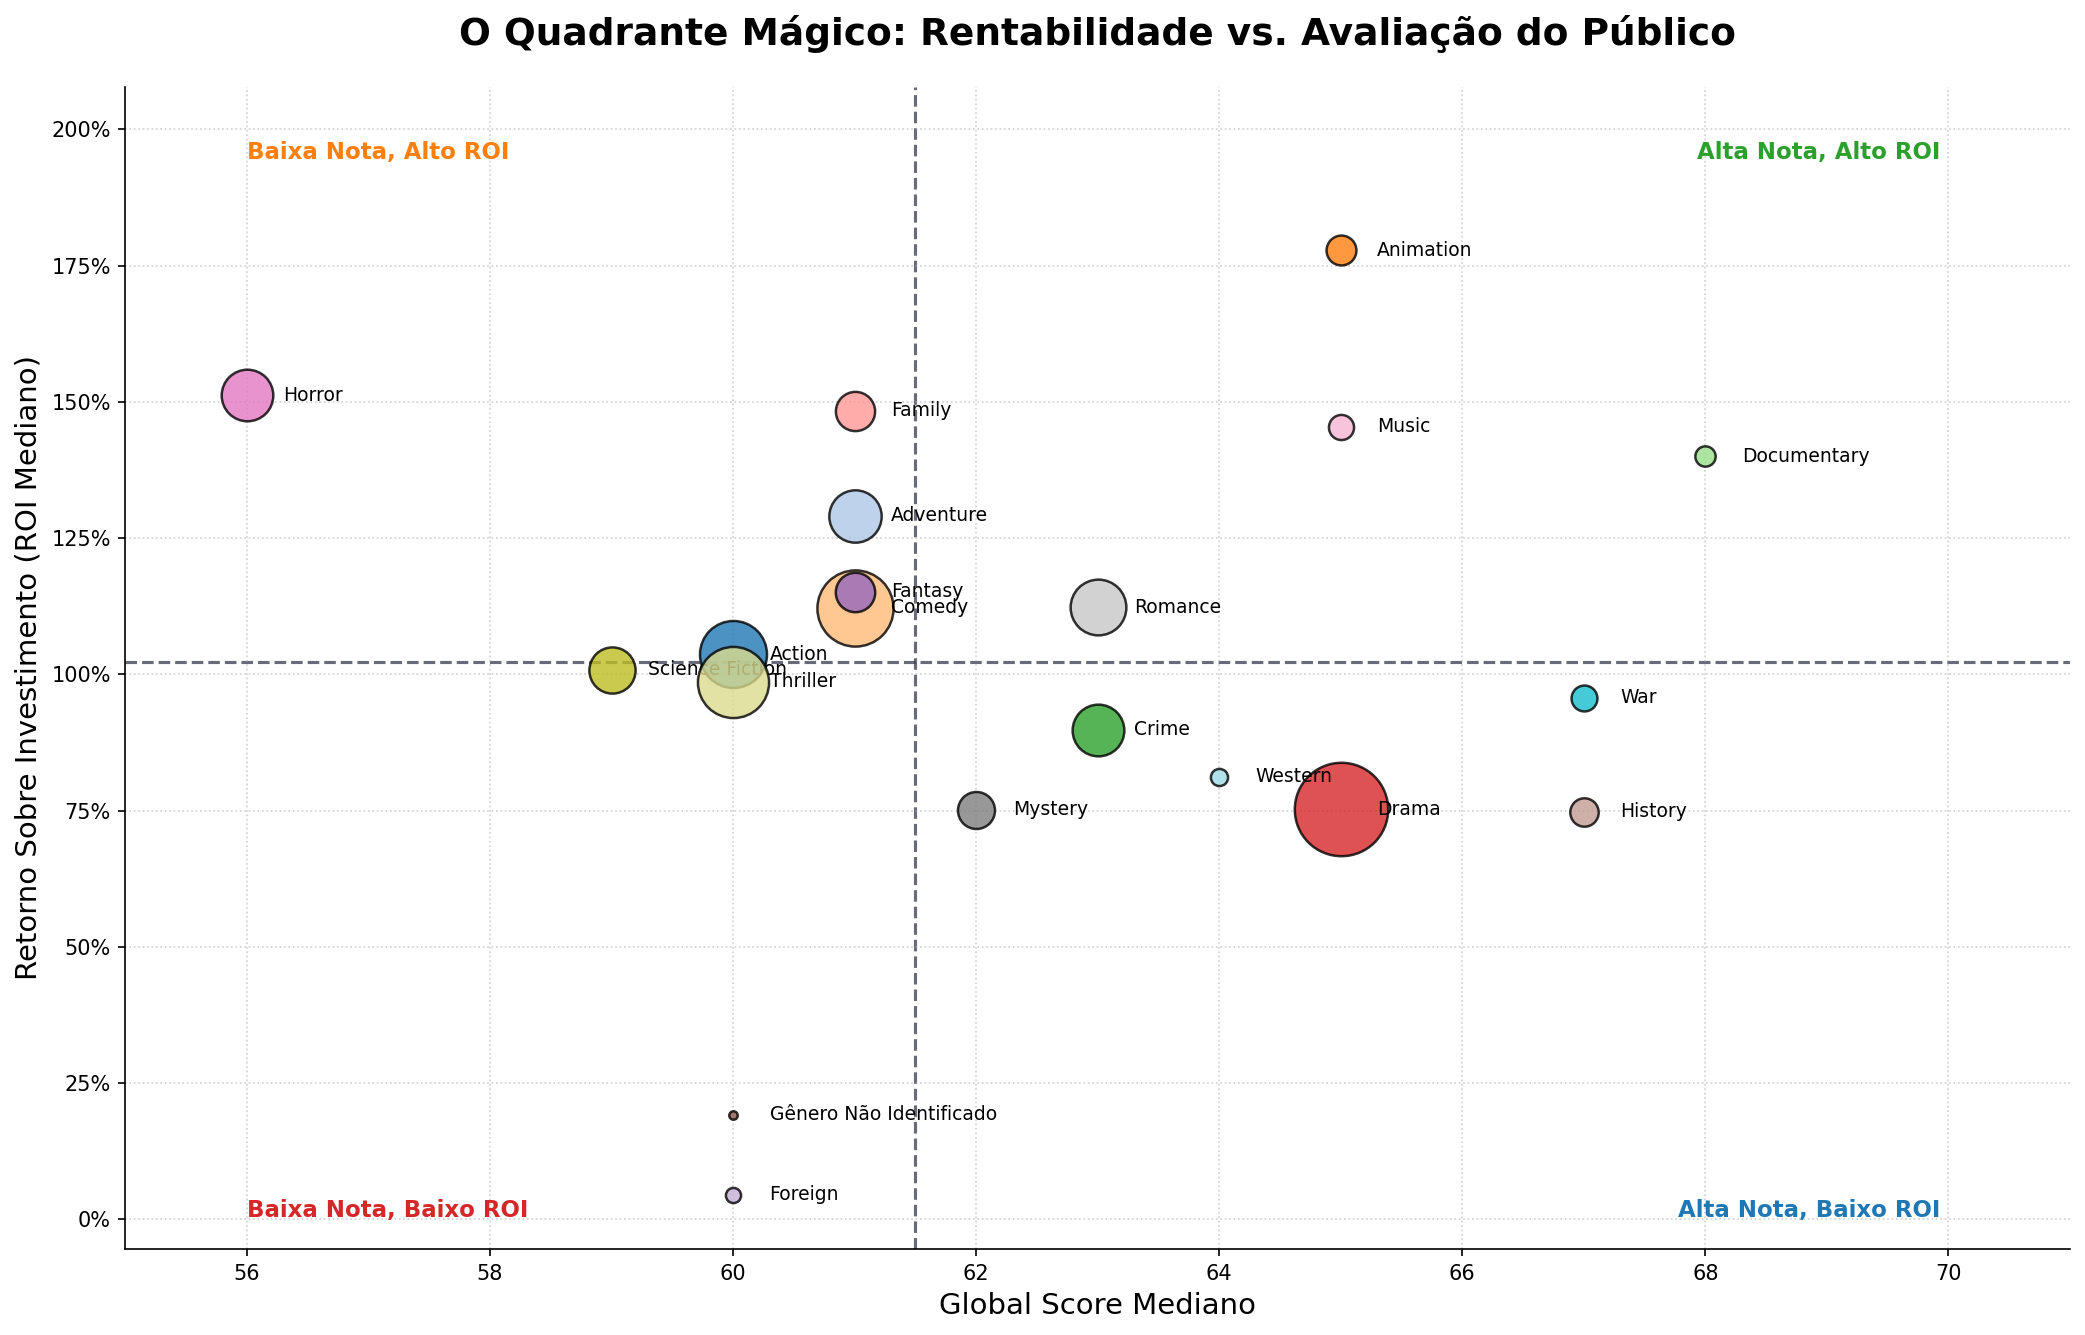

In [11]:
# Removendo 'TV Movie' para não distorcer a escala
df_plot = df_score_roi_genres[df_score_roi_genres['genres'] != 'TV Movie'].copy()


plt.figure(figsize=(14, 9), dpi=150)

x = df_plot['global_score_mediano']
y = df_plot['roi_mediano']


cores = plt.cm.tab20(np.linspace(0, 1, len(df_plot)))

for i, (_, row) in enumerate(df_plot.iterrows()):
    plt.scatter(
        row['global_score_mediano'],
        row['roi_mediano'],
        s=row['quantidade_filmes'] * 0.5, 
        color=cores[i],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        zorder=3
    )


    plt.text(
        row['global_score_mediano'] + 0.3,
        row['roi_mediano'],
        f"{row['genres']}",
        fontsize=9,
        va='center',
        fontweight='medium'
    )


score_mediano = x.median()
roi_mediano = y.median()

plt.axvline(score_mediano, color='#2B2D42', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
plt.axhline(roi_mediano, color='#2B2D42', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

x_min, x_max = x.min() - 1, x.max() + 3
y_min, y_max = y.min() - 10, y.max() + 30

plt.text(x_max - 1, y_max - 10, "Alta Nota, Alto ROI ", fontsize=11, fontweight='bold', color='#2CA02C', ha='right', va='top')
plt.text(x_min + 1, y_max - 10, "Baixa Nota, Alto ROI ", fontsize=11, fontweight='bold', color='#FF7F0E', ha='left', va='top')
plt.text(x_max - 1, y_min + 5, "Alta Nota, Baixo ROI ", fontsize=11, fontweight='bold', color='#1F77B4', ha='right', va='bottom')
plt.text(x_min + 1, y_min + 5, "Baixa Nota, Baixo ROI ", fontsize=11, fontweight='bold', color='#D62728', ha='left', va='bottom')


plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda valor, _: f'{valor:.0f}%'))

plt.title('O Quadrante Mágico: Rentabilidade vs. Avaliação do Público', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Global Score Mediano', fontsize=14, fontweight='medium')
plt.ylabel('Retorno Sobre Investimento (ROI Mediano)', fontsize=14, fontweight='medium')

plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
sns.despine()

plt.tight_layout()
plt.show()

In [12]:
dbc.save_db(
    df=df_score_roi_genres,
    pasta='../../data/processed',
    nome_banco='unified_media_catalog',
    nome_tabela='cinema_financial_genres'
)

# Para uso no Power BI
df_score_roi_genres.to_excel(
    '../../data/powerbi_export/cinema_financial_genres.xlsx', 
    index=False
)


Sucesso! Tabela 'cinema_financial_genres' criada no banco: 'unified_media_catalog.db'


---
## Conclusões: O Quadrante Mágico e a Fórmula do Lucro

A nossa análise cruzada entre os indicadores financeiros (Orçamento e ROI) e a percepção do público (Nota Global) revela que não existe apenas uma forma de fazer dinheiro no cinema, mas sim estratégias distintas baseadas no apetite ao risco de cada estúdio.

**1. O Custo do Gênero (A Escala vs. O Nicho)**

* **A Descoberta:** Os orçamentos do Cinema vivem em extremos. Gêneros voltados para o entretenimento de massas (Aventura, Animação, Família e Fantasia) exigem orçamentos medianos altíssimos (entre US$ 25M e US$ 30M). Na outra ponta, Documentários, Filmes Estrangeiros e Terror sobrevivem com orçamentos "independentes" (US$ 500k a US$ 3.5M).

* **O Racional de Negócio:** Gêneros caros precisam agradar o mundo inteiro; o alto investimento é justificado pelo pesado uso de efeitos visuais (CGI) e elencos estelares para garantir bilheterias globais. Já os gêneros mais baratos não refletem uma "falta de aposta" dos estúdios, mas sim a natureza ágil da produção. Um documentário usa locações reais e o terror apoia-se em efeitos práticos, suspense e atores desconhecidos, mantendo os custos no chão.

**2. A Eficiência do Retorno (Os Dois Caminhos para o Alto ROI)**

* **A Descoberta:** Ignorando os "TV Movies" (cujas receitas de licenciamento e publicidade distorcem a métrica tradicional de bilheteria), o Top de rentabilidade revela uma dualidade fantástica. Encontramos tanto os gêneros mais caros (Animação com 177% e Família com 148%) quanto os mais baratos (Terror com 151% e Documentário com 140%).

* **O Racional de Negócio:** A matemática prova que existem dois modelos vitoriosos para um alto ROI. O Modelo de Escala: gasta-se uma fortuna em Animação/Família, mas o apelo demográfico (pais levando filhos ao cinema) e a venda de merchandising garantem margens monumentais. E o Modelo de Baixo Risco: gasta-se uma fração mínima em Terror/Documentários, onde qualquer desempenho aceitável na bilheteria se transforma num ROI percentual astronômico.

**3.O Quadrante Mágico do Cinema (Lucro vs. Prestígio)**

* **A Descoberta:** O gráfico de dispersão mapeia perfeitamente as intenções da indústria:

  * Estrelas do Mercado (Alta Nota, Alto ROI): Animação, Família e Música. O "pote de ouro" que une excelência e rios de dinheiro.

  * Caça-Níqueis (Baixa Nota, Alto ROI): O Terror domina absoluto. O público critica severamente, mas continua pagando para assistir.

  * Prestígio Crítico (Alta Nota, Baixo ROI): História e Drama. Filmes premiados, que constroem a marca e o legado de um estúdio, mas que operam com margens financeiras difíceis e perigosas.

  * A Zona de Risco (Baixa Nota, Baixo ROI): Ação, Thriller e Ficção Científica. Gêneros que, apesar de gerarem blockbusters pontuais, apresentam uma mediana perigosa: custam muito caro para produzir, dividem a opinião pública e entregam um ROI abaixo do esperado. Curiosamente, este quadrante também abriga o extremo oposto: filmes Estrangeiros (Foreign) e com Gênero Não Identificado, que falham criticamente em atrair público em compração aos demais gêneros.

* **O Racional de Negócio:** O Cinema não escolhe entre dinheiro ou prestígio; ela aloca recursos estrategicamente. Os estúdios produzem Terror para fazer "caixa rápido" e mitigar os riscos financeiros, usam a Animação e os filmes de Família para construir impérios financeiros sustentáveis, e financiam Dramas Históricos quase como um "investimento em marketing" visando o Oscar e o prestígio cultural.